In [1]:
from IPython.display import HTML
HTML('''
    <style> body {font-family: "Roboto Condensed Light", "Roboto Condensed";} h2 {padding: 10px 12px; background-color: #E64626; position: static; color: #ffffff; font-size: 40px;} .text_cell_render p { font-size: 15px; } .text_cell_render h1 { font-size: 30px; } h1 {padding: 10px 12px; background-color: #E64626; color: #ffffff; font-size: 40px;} .text_cell_render h3 { padding: 10px 12px; background-color: #0148A4; position: static; color: #ffffff; font-size: 20px;} h4:before{ 
    content: "@"; font-family:"Wingdings"; font-style:regular; margin-right: 4px;} .text_cell_render h4 {padding: 8px; font-family: "Roboto Condensed Light"; position: static; font-style: italic; background-color: #FFB800; color: #ffffff; font-size: 18px; text-align: center; border-radius: 5px;}input[type=submit] {background-color: #E64626; border: solid; border-color: #734036; color: white; padding: 8px 16px; text-decoration: none; margin: 4px 2px; cursor: pointer; border-radius: 20px;}</style>
''')

# Primary School Data

In [3]:
#Importing all Libraries that may be necessary
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point, Polygon, MultiPolygon
from geoalchemy2 import Geometry, WKTElement
import matplotlib.pyplot as plt

In [4]:
#Reading in the Data into a GeoDataFrame
relative_path = "Catchments\catchments\catchments_primary.shp"
primary_schools = gpd.read_file(relative_path)

Index(['USE_ID', 'CATCH_TYPE', 'USE_DESC', 'ADD_DATE', 'KINDERGART', 'YEAR1',
       'YEAR2', 'YEAR3', 'YEAR4', 'YEAR5', 'YEAR6', 'YEAR7', 'YEAR8', 'YEAR9',
       'YEAR10', 'YEAR11', 'YEAR12', 'PRIORITY', 'geometry'],
      dtype='object')


In [6]:
# Rename 'Kindegart' column to YEAR0 to better fit the column name format
primary_schools.rename(columns={'KINDERGART':'YEAR0'}, inplace=True)

In [7]:
#Print out the number of Primary Schools that accept each Year
for n in range(13):
    N = primary_schools[primary_schools['YEAR' + str(n)] == 'Y']
    print(f'{n} : {len(N)}')
# This is to catch out any irregularities 

0 : 1662
1 : 1662
2 : 1662
3 : 1648
4 : 1648
5 : 1648
6 : 1648
7 : 0
8 : 0
9 : 0
10 : 0
11 : 0
12 : 0


As expected, the entries for years 7-12 (High School Years) are all 0. Although, we notice a drop of 14 schools when transitioning from Year 2-3.

In [8]:
# Print out all schools which Accept Year 2, but NOT Year 3
X =primary_schools.loc[(primary_schools['YEAR0'] == 'Y') & (primary_schools['YEAR3'] == 'N')]
X

,USE_ID,CATCH_TYPE,USE_DESC,ADD_DATE,YEAR0,YEAR1,YEAR2,YEAR3,YEAR4,YEAR5,YEAR6,YEAR7,YEAR8,YEAR9,YEAR10,YEAR11,YEAR12,PRIORITY,geometry
7,5148,INFANTS,Bardwell Park IS,None,Y,Y,Y,N,N,N,N,N,N,N,N,N,N,None,"POLYGON ((151.12810 -33.93058, 151.12831 -33.9..."
96,5246,INFANTS,Bankstown SIS,None,Y,Y,Y,N,N,N,N,N,N,N,N,N,N,None,"POLYGON ((151.04289 -33.91783, 151.04325 -33.9..."
174,5103,INFANTS,Arncliffe WIS,None,Y,Y,Y,N,N,N,N,N,N,N,N,N,N,None,"POLYGON ((151.15536 -33.92675, 151.15232 -33.9..."
198,5128,INFANTS,Nillo IS,None,Y,Y,Y,N,N,N,N,N,N,N,N,N,N,None,"POLYGON ((151.56698 -32.73101, 151.56640 -32.7..."
279,5120,INFANTS,Yeo Park IS,20140410,Y,Y,Y,N,N,N,N,N,N,N,N,N,N,None,"POLYGON ((151.14494 -33.88995, 151.14496 -33.8..."
290,5241,INFANTS,Mt Lewis IS,None,Y,Y,Y,N,N,N,N,N,N,N,N,N,N,None,"POLYGON ((151.04192 -33.91255, 151.04188 -33.9..."
541,5247,INFANTS,New Lambton Hts IS,20200717,Y,Y,Y,N,N,N,N,N,N,N,N,N,N,None,"POLYGON ((151.68110 -32.93051, 151.68141 -32.9..."
591,5112,INFANTS,Taverners Hill IS,None,Y,Y,Y,N,N,N,N,N,N,N,N,N,N,None,"POLYGON ((151.16941 -33.87425, 151.16867 -33.8..."
629,5188,INFANTS,Sefton IS,None,Y,Y,Y,N,N,N,N,N,N,N,N,N,N,None,"POLYGON ((150.99655 -33.88759, 150.99653 -33.8..."
696,5104,INFANTS,Australia St IS,None,Y,Y,Y,N,N,N,N,N,N,N,N,N,N,None,"POLYGON ((151.17700 -33.89326, 151.17725 -33.8..."


From this we can see that the drop of 14 was correctly documented, as all these schools are of Catch Type 'Infant', and so are not an irregularity in the dataset in need of cleaning.

Looking at Null Values, there are a large proportion present in both Add_Year, and Priority. Further investigation below reveals ~20% of the ADD_DATE column is empty. Whilst this is a large proportion, this column is likely unecessary for our overall analysis, and so can be left as is.

In [20]:
date_null = len(primary_schools[primary_schools.ADD_DATE.isnull()])
date_total = len(primary_schools.ADD_DATE)

print(f'Total Entries: {date_total}')
print(f'Null Entries: {date_null}')

Total Entries: 1662
Null Entries: 327


In contrast, the PRIORITY column is entire Null values, save for 4 entries of 'N'. Which remain ambiguous as to whether it means 'No' or simply another choice of 'Null' or 'None'. 
As a result this column should be ignored, as far too much of it is empty.

In [24]:
priority_null = len(primary_schools[primary_schools.PRIORITY.isnull()])
priority_total = len(primary_schools.PRIORITY)

print(f'Total Entries: {priority_total}')
print(f'Null Entries: {priority_null}')
print(primary_schools.PRIORITY.unique()) #What values are there other than None?

Total Entries: 1662
Null Entries: 1658
[None 'N']


Looking at the geometry column, graphing it we can see where there are gaps in the data. The largest of these gaps is identifiably the ACT, and so is expectedly absent. In addition there are less explainable gaps just north of the ACT, and in nearby Sydney.

(-34.0, -33.3)

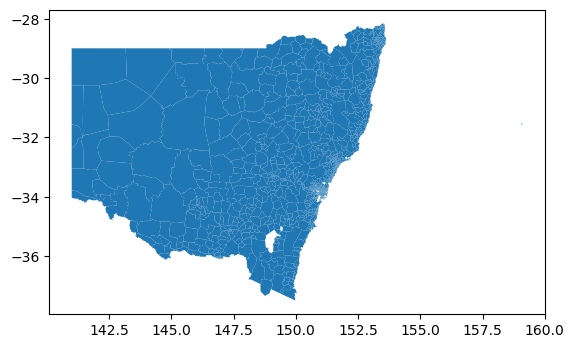

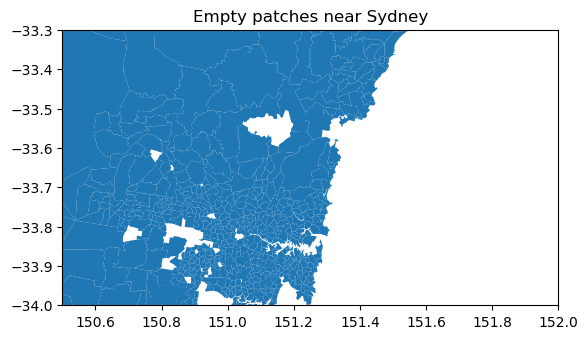

In [31]:
primary_schools.plot()
primary_schools.plot() #Zoomed in on Sydney
plt.title('Empty patches near Sydney')
plt.xlim(150.5,152)
plt.ylim(-34,-33.3)

Checking to see what kind of Geometries our schools can be reveals we have both Polygons, and Multipolygons. Finding which rows are polygons and which are multipolygons I have not yet done.

In [52]:
geometry_types = []
for row in primary_schools.geometry:
    geometry_types.append(type(row))
geometry_types = list(set(geometry_types)) #set() turns it into a set, removing duplicates. A rather untidy way of finding unique values
geometry_types

[shapely.geometry.polygon.Polygon, shapely.geometry.multipolygon.MultiPolygon]

# High Schools

In [32]:
# Importing Data
relative_path = "Catchments\catchments\catchments_secondary.shp"
secondary_schools = gpd.read_file(relative_path)
secondary_schools.rename(columns={'KINDERGART':'YEAR0'}, inplace=True) #Renaming Kindergart Column, same as primary schools.

Repeating the same investigation of each year accepted reveals far more 'turbulence' than with the primary schools. As expected, years 0-6 are all 0, but there are strange drop offs for each year.

In [33]:
for n in range(13):
    N = secondary_schools[secondary_schools['YEAR' + str(n)] == 'Y']
    print(f'{n} : {len(N)}')

0 : 0
1 : 0
2 : 0
3 : 0
4 : 0
5 : 0
6 : 0
7 : 423
8 : 422
9 : 420
10 : 420
11 : 413
12 : 411


Noting that Year 7 is only a single entry higher than 8, I was interested in finding whether this was an anomaly.
This reveals that Lord Howe Island Central School was the anomaly. More importantly, its website reveals 
https://lordhowe-c.schools.nsw.gov.au/learning-at-our-school/secondary.html 
'Whilst named a Central School, Lord Howe Island Central School provides face to face teaching for students in K-6 only. Secondary aged students resident on Lord Howe Island who are enrolled at Camden Haven High School Distance Education Centre complete their work provided by their teachers from CHDEC with support from their supervisors. Students are assisted in their learning by LHICS in various ways. eg resources and facilities.'

This makes it clear that Lord Howe ICS should not be classified this way.

In [34]:
# Schools where Year 7 is true, but Year 8 is false.
X = secondary_schools.loc[(secondary_schools['YEAR7'] == 'Y') & (secondary_schools['YEAR8'] == 'N')]
X

,USE_ID,CATCH_TYPE,USE_DESC,ADD_DATE,YEAR0,YEAR1,YEAR2,YEAR3,YEAR4,YEAR5,YEAR6,YEAR7,YEAR8,YEAR9,YEAR10,YEAR11,YEAR12,PRIORITY,geometry
72,1921,CENTRAL_HIGH,Lord Howe ICS,20210702,N,N,N,N,N,N,N,Y,N,N,N,N,N,None,"POLYGON ((159.06474 -31.50980, 159.06479 -31.5..."


Looking at the two schools which stop taking students at Year 9 can be traced into the 'Future Schools' Table, where it becomes evident that this is intentional, and they will begin taking older students in the years to come.

In [35]:
X = secondary_schools.loc[(secondary_schools['YEAR8'] == 'Y') & (secondary_schools['YEAR9'] == 'N')]
X

,USE_ID,CATCH_TYPE,USE_DESC,ADD_DATE,YEAR0,YEAR1,YEAR2,YEAR3,YEAR4,YEAR5,YEAR6,YEAR7,YEAR8,YEAR9,YEAR10,YEAR11,YEAR12,PRIORITY,geometry
380,8919,HIGH_COED,Bungendore HS,20230112,N,N,N,N,N,N,N,Y,Y,N,N,N,N,Y,"POLYGON ((149.24085 -34.91439, 149.24367 -34.9..."
381,8922,HIGH_COED,Jerrabomberra HS,20230112,N,N,N,N,N,N,N,Y,Y,N,N,N,N,Y,"POLYGON ((149.20600 -35.37104, 149.20764 -35.3..."


The drop off from Year10 -> Year 11 is believable as there are specialised schools for 'Senior Students'. Although the drop from Year11 -> 12 is stranger, and this reveals 2 schools. Oran Park HS is once again in our Future Schools Table, although states all years for 2024, and so this may still be an error. Wilcania is absent.

In [38]:
X = secondary_schools.loc[(secondary_schools['YEAR11'] == 'Y') & (secondary_schools['YEAR12'] == 'N')]
X

,USE_ID,CATCH_TYPE,USE_DESC,ADD_DATE,YEAR0,YEAR1,YEAR2,YEAR3,YEAR4,YEAR5,YEAR6,YEAR7,YEAR8,YEAR9,YEAR10,YEAR11,YEAR12,PRIORITY,geometry
131,8916,HIGH_COED,Oran Park HS,20200310,N,N,N,N,N,N,N,Y,Y,Y,Y,Y,N,N,"POLYGON ((150.75452 -33.95472, 150.75653 -33.9..."
354,3442,CENTRAL_HIGH,Wilcannia CS,20191226,N,N,N,N,N,N,N,Y,Y,Y,Y,Y,N,None,"POLYGON ((144.62996 -31.18538, 144.63139 -31.1..."


Looking at Wilcania CS's website: https://wilcannia-c.schools.nsw.gov.au/learning-at-our-school.html, shows signs that it does in fact offer all years from K-12, although potentially with some special programs for certain years. Regardless, this may be an anomaly. In addition, by separating schools into 'Primary' and 'Secondary' there are no recorded schools that accept students from K-12, which is clearly incorrect. But once again, this column is not vital.

Continuing investigation to the previously odd 'PRIORITIES' Column. This once again reveals it is largely None, although unlike Primary Schools we know see the value 'Y', which lends to the idea that is is 'N'= No, 'Y' = Yes. Regardless, what Priority means is still ambiguous.

In [43]:
priority_null = len(secondary_schools[secondary_schools.PRIORITY.isnull()])
priority_total = len(secondary_schools.PRIORITY)
print(f'Total Entries: {priority_total}')
print(f'Null Entries: {priority_null}')
print(secondary_schools.PRIORITY.unique()) #What values are there other than None?

Total Entries: 436
Null Entries: 429
[None 'Y' 'N']


Plotting the Span of the Catchments of Secondary schools once again shows ACT absent, and a few smaller, but still present gaps in the Sydney area

(-34.0, -33.3)

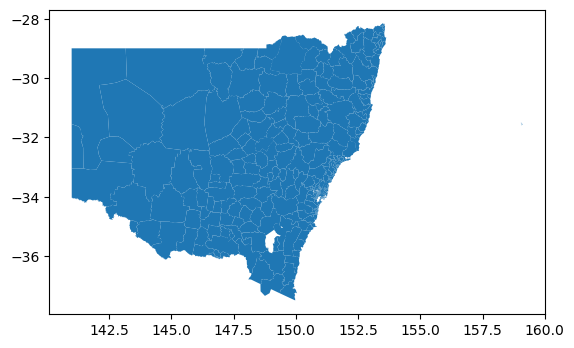

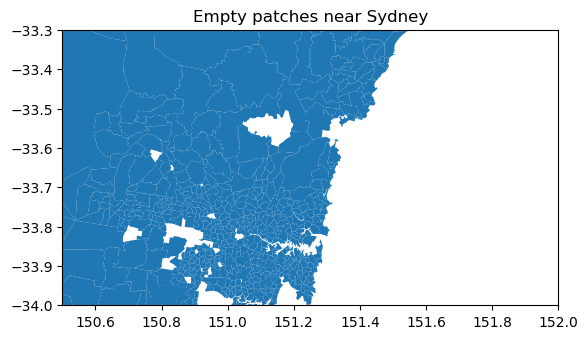

In [45]:
secondary_schools.plot()
primary_schools.plot() #Zoomed in on Sydney
plt.title('Empty patches near Sydney')
plt.xlim(150.5,152)
plt.ylim(-34,-33.3)

# Future Schools

In [46]:
relative_path = "Catchments\catchments\catchments_future.shp"
future_schools = gpd.read_file(relative_path)
future_schools.head(3)

,USE_ID,CATCH_TYPE,USE_DESC,ADD_DATE,KINDERGART,YEAR1,YEAR2,YEAR3,YEAR4,YEAR5,YEAR6,YEAR7,YEAR8,YEAR9,YEAR10,YEAR11,YEAR12,geometry
0,8416,HIGH_COED,Ku-ring-gai HS,20230114,0,0,0,0,0,0,0,2024,2024,2024,2024,2024,2024,"POLYGON ((151.19849 -33.53990, 151.19945 -33.5..."
1,8161,HIGH_BOYS,Randwick BHS,20200220,0,0,0,0,0,0,0,2024,2024,2024,2024,2024,2024,"POLYGON ((151.27152 -33.91402, 151.27152 -33.9..."
2,8539,HIGH_COED,SSC Blackwattle Bay,20220609,0,0,0,0,0,0,0,0,0,0,0,2024,2024,"POLYGON ((151.15292 -33.83939, 151.16144 -33.8..."


It is worth noting that many entries in the 'Future Schools' table state 2024 as the future, and now being present remain ambiguous to the actual state of these schools. Have they been built, and are they operational? This remains unknown

We can see the location of where all the new schools are planned. Most notably, some seem to be filling in the gaps missing in the previous tables. (around Sydney)

<Axes: >

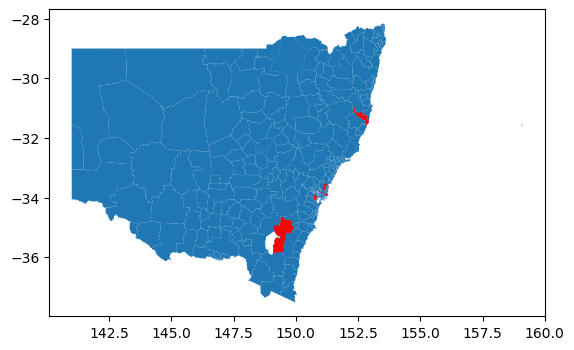

In [54]:
fig, ax1 = plt.subplots()
secondary_schools.plot(ax=ax1)
future_schools.plot(ax=ax1, color='red')